In [5]:
# Ячейка 1: Загрузка (без seaborn)
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns  # временно убрали

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"\nFraud rate: {train['is_fraud'].mean():.4f}")
print(f"\nTrain period: {train['timestamp'].min()} - {train['timestamp'].max()}")
print(f"Test period: {test['timestamp'].min()} - {test['timestamp'].max()}")

Train shape: (374891, 17)
Test shape: (147988, 16)

Fraud rate: 0.0069

Train period: 2025-01-01 00:00:00.000000000 - 2025-04-30 23:59:59.000000000
Test period: 2025-05-01 00:00:00.000000000 - 2025-06-15 23:59:59.000000000


In [6]:
# Проверка пропусков
print("Train пропуски:")
print(train.isnull().sum())
print("\nTest пропуски:")
print(test.isnull().sum())

Train пропуски:
transaction_id            0
customer_id               0
timestamp                 0
amount                    0
merchant_category         0
merchant_id               0
channel                   0
device_id            129504
is_foreign                0
card_present              0
region                    0
age                       0
income_bracket        26707
account_age_days          0
review_status        279146
chargeback_amount         0
is_fraud                  0
dtype: int64

Test пропуски:
transaction_id           0
customer_id              0
timestamp                0
amount                   0
merchant_category        0
merchant_id              0
channel                  0
device_id            29235
is_foreign               0
card_present             0
region                   0
age                      0
income_bracket       10563
account_age_days         0
review_status        74022
chargeback_amount        0
dtype: int64


In [ ]:
# Эти поля недоступны в момент транзакции!
print("review_status в train:")
print(train['review_status'].value_counts(dropna=False))
print(f"\nchargeback_amount > 0 в train: {(train['chargeback_amount'] > 0).sum()}")
print(f"chargeback_amount > 0 в test: {(test['chargeback_amount'] > 0).sum()}")
print("\n Это постфактум признаки - их нельзя использовать!")

review_status в train:
review_status
NaN                279146
cleared             93157
confirmed_fraud      2321
under_review          267
Name: count, dtype: int64

chargeback_amount > 0 в train: 2211
chargeback_amount > 0 в test: 0

⚠️ Это постфактум признаки - их нельзя использовать!


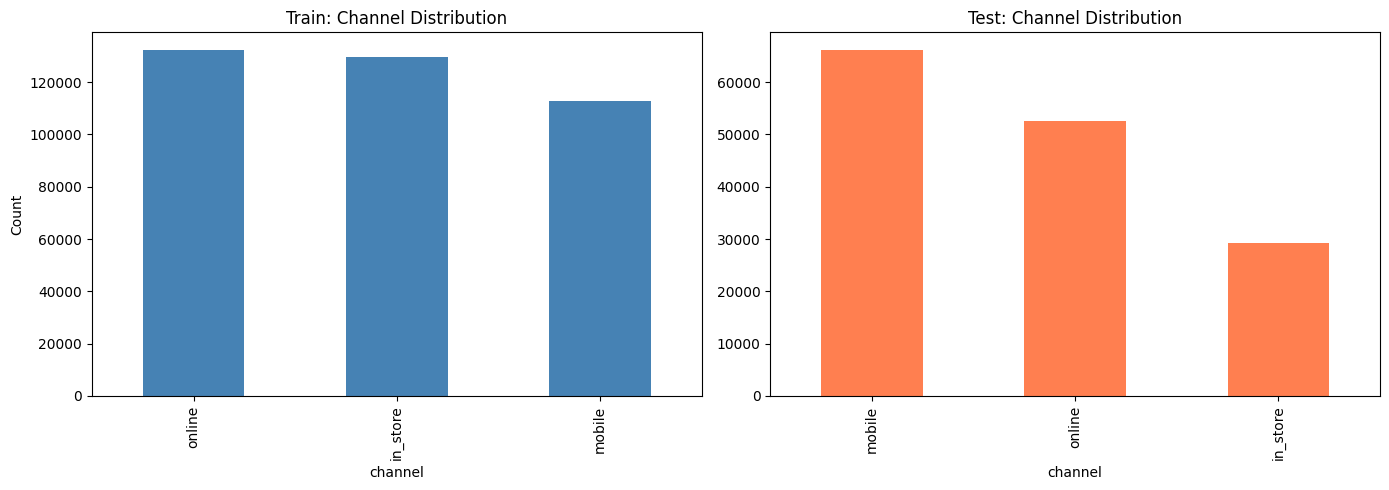


Fraud rate по каналам:
channel
online      0.013983
mobile      0.006516
in_store    0.000000
Name: is_fraud, dtype: float64


In [8]:
# Каналы транзакций
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train['channel'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Train: Channel Distribution')
axes[0].set_ylabel('Count')

test['channel'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Test: Channel Distribution')

plt.tight_layout()
plt.show()

# Fraud rate по каналам
print("\nFraud rate по каналам:")
print(train.groupby('channel')['is_fraud'].mean().sort_values(ascending=False))

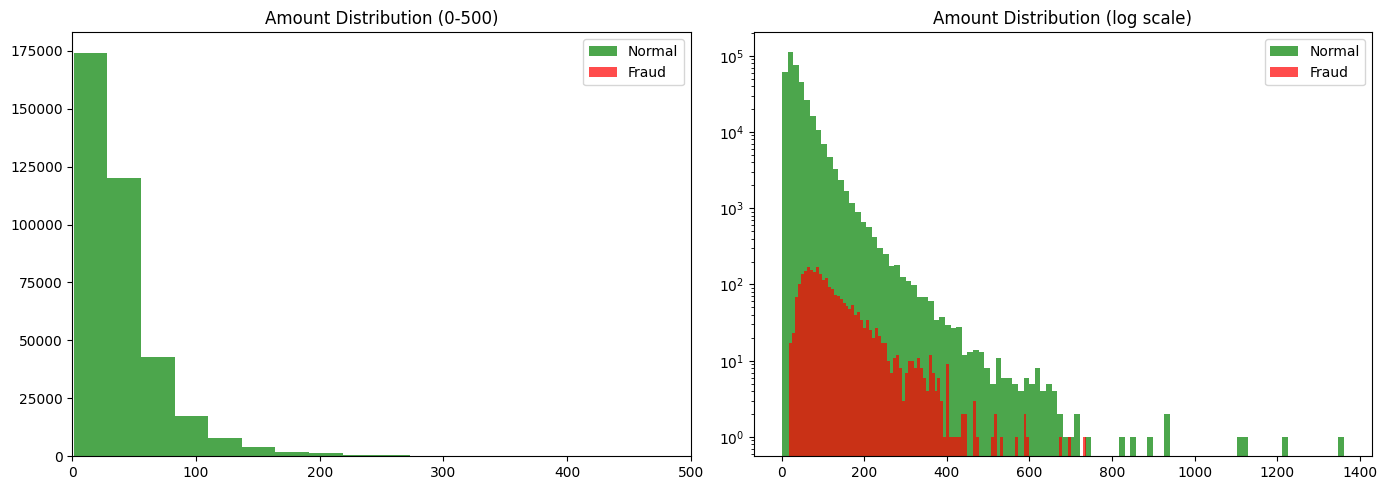


Средняя сумма normal: 40.64
Средняя сумма fraud: 123.40


In [9]:
# Распределение сумм
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train[train['is_fraud']==0]['amount'], bins=50, alpha=0.7, label='Normal', color='green')
axes[0].hist(train[train['is_fraud']==1]['amount'], bins=50, alpha=0.7, label='Fraud', color='red')
axes[0].set_xlim(0, 500)
axes[0].set_title('Amount Distribution (0-500)')
axes[0].legend()

axes[1].hist(train[train['is_fraud']==0]['amount'], bins=100, alpha=0.7, label='Normal', color='green')
axes[1].hist(train[train['is_fraud']==1]['amount'], bins=100, alpha=0.7, label='Fraud', color='red')
axes[1].set_title('Amount Distribution (log scale)')
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nСредняя сумма normal: {train[train['is_fraud']==0]['amount'].mean():.2f}")
print(f"Средняя сумма fraud: {train[train['is_fraud']==1]['amount'].mean():.2f}")

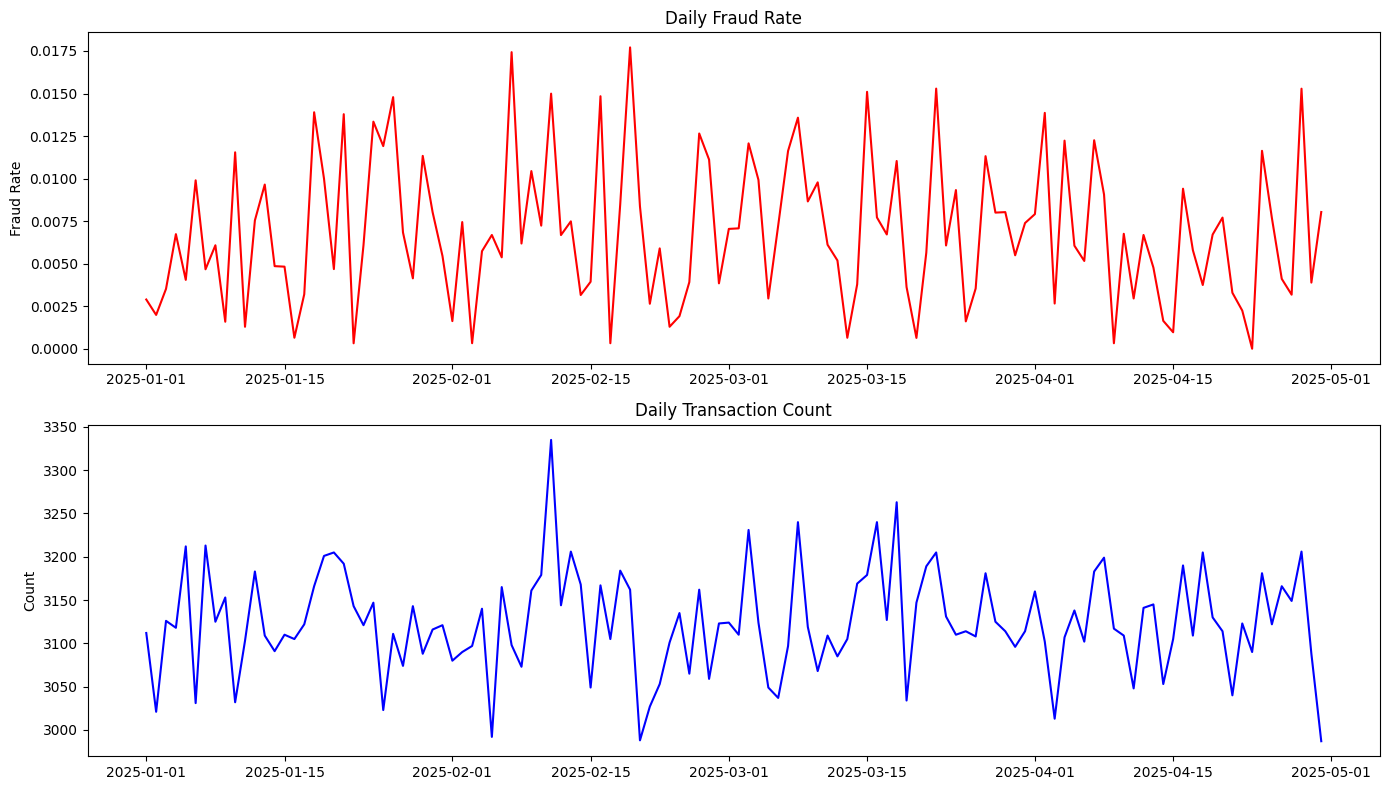

In [10]:
# Fraud по дням
train['date'] = pd.to_datetime(train['timestamp']).dt.date
daily_fraud = train.groupby('date')['is_fraud'].agg(['mean', 'count'])

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(daily_fraud.index, daily_fraud['mean'], color='red')
axes[0].set_title('Daily Fraud Rate')
axes[0].set_ylabel('Fraud Rate')

axes[1].plot(daily_fraud.index, daily_fraud['count'], color='blue')
axes[1].set_title('Daily Transaction Count')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Fraud rate по категориям:
                   fraud_rate  count
merchant_category                   
gambling             0.068216   5981
electronics          0.037406  27509
travel               0.031880  18789
online_services      0.017875  30881
clothing             0.000000  45104
fuel                 0.000000  44819
health               0.000000  25263
grocery              0.000000  74125
restaurant           0.000000  59857
utilities            0.000000  42563

Fraud rate по категориям x канал:
channel            in_store    mobile    online
merchant_category                              
clothing                0.0  0.000000  0.000000
electronics             0.0  0.036390  0.071868
fuel                    0.0  0.000000  0.000000
gambling                0.0  0.064117  0.131544
grocery                 0.0  0.000000  0.000000
health                  0.0  0.000000  0.000000
online_services         0.0  0.015910  0.036248
restaurant              0.0  0.000000  0.000000
travel         

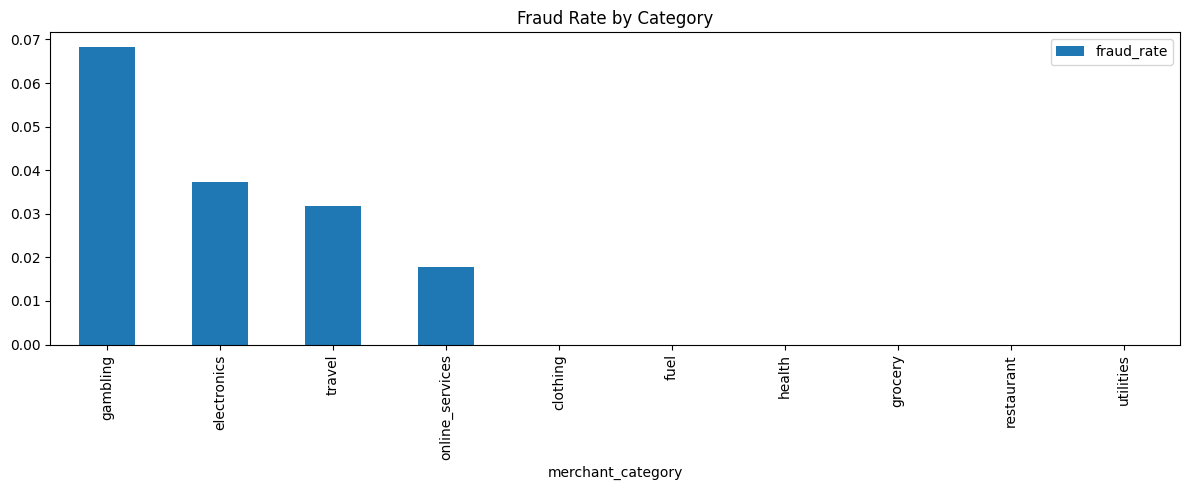

In [11]:
# Fraud по категориям и каналам
print("Fraud rate по категориям:")
fraud_by_cat = train.groupby('merchant_category').agg(
    fraud_rate=('is_fraud', 'mean'),
    count=('is_fraud', 'count')
).sort_values('fraud_rate', ascending=False)
print(fraud_by_cat.head(10))

print("\nFraud rate по категориям x канал:")
fraud_pivot = train.pivot_table(
    values='is_fraud', 
    index='merchant_category', 
    columns='channel', 
    aggfunc='mean'
)
print(fraud_pivot)

# Топ-10 категорий
fraud_by_cat.head(10).plot(kind='bar', y='fraud_rate', figsize=(12, 5))
plt.title('Fraud Rate by Category')
plt.tight_layout()
plt.show()

In [12]:
# Проверяем, точно ли нет fraud в in_store
in_store = train[train['channel'] == 'in_store']
print(f"In_store транзакций: {len(in_store)}")
print(f"In_store fraud: {in_store['is_fraud'].sum()}")

# Смотрим комбинации channel x card_present
print("\nFraud rate по channel x card_present:")
print(train.groupby(['channel', 'card_present'])['is_fraud'].mean())

In_store транзакций: 129504
In_store fraud: 0

Fraud rate по channel x card_present:
channel   card_present
in_store  1               0.000000
mobile    0               0.006516
online    0               0.013983
Name: is_fraud, dtype: float64


In [13]:
# Ячейка 9: Бизнес-правила для baseline
def apply_rules(df):
    df = df.copy()
    
    # Если in_store или card_present=1 → fraud=0 (100% точность в train)
    df['rule_1_in_store'] = ((df['channel'] == 'in_store') | (df['card_present'] == 1)).astype(int)
    
    # Если категория безопасная → низкий риск
    safe_cats = ['clothing', 'fuel', 'health', 'grocery', 'restaurant', 'utilities']
    df['rule_2_safe_cat'] = df['merchant_category'].isin(safe_cats).astype(int)
    
    # Если gambling + online → высокий риск
    df['rule_3_gambling_online'] = ((df['merchant_category'] == 'gambling') & (df['channel'] == 'online')).astype(int)
    
    # Комбинированное правило
    df['rule_score'] = df['rule_3_gambling_online'] * 0.5 + (~df['rule_2_safe_cat'].astype(bool)).astype(int) * 0.1
    
    return df

train_with_rules = apply_rules(train)
test_with_rules = apply_rules(test)

# Проверяем точность правил
print("Правило 1 (in_store): охват =", train_with_rules['rule_1_in_store'].sum())
print("Правило 2 (безопасные категории): охват =", train_with_rules['rule_2_safe_cat'].sum())
print("Правило 3 (gambling online): охват =", train_with_rules['rule_3_gambling_online'].sum())

Правило 1 (in_store): охват = 129504
Правило 2 (безопасные категории): охват = 291731
Правило 3 (gambling online): охват = 2235
